In [16]:
import argparse
from model.TSPN import Transparent_Signal_Processing_Network
from trainer.trainer_basic import Basic_plmodel

import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [17]:
parser = argparse.ArgumentParser(description='TSPN')
parser.add_argument('--config_dir', type=str, default='configs/a_031_HUST/config_basic.yaml',help='The directory of the configuration file')
# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
signal_processing_modules, feature_extractor_modules = config_network(configs,args)

Running experiment: model_TSPNtime25-15-18-42_datasetHUST_031_Basic_it0


In [18]:
MODEL_DICT = {'TSPN': lambda args: Transparent_Signal_Processing_Network(signal_processing_modules, feature_extractor_modules,args)}
model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_tson_hust_20hz.ckpt")
model.load_state_dict(state_dict['state_dict'])
print(model)


# build signal processing layers
# build feature extractor layers
# build classifier
Basic_plmodel(
  (network): Transparent_Signal_Processing_Network(
    (signal_processing_layers): ModuleList(
      (0): SignalProcessingLayer(
        (norm): InstanceNorm1d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (weight_connection): Linear(in_features=3, out_features=12, bias=True)
        (signal_processing_modules): SignalProcessingModuleDict(
          (HT): HilbertTransform()
          (LNO): Laplace_neural_operator()
          (I): Identity()
        )
        (skip_connection): Linear(in_features=3, out_features=12, bias=True)
      )
      (1-3): 3 x SignalProcessingLayer(
        (norm): InstanceNorm1d(12, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (weight_connection): Linear(in_features=12, out_features=12, bias=True)
        (signal_processing_modules): SignalProcessingModuleDict(
          (HT): HilbertTransform()
      

C:\Users\CCSLab\AppData\Local\Temp\ipykernel_12056\3071606506.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("./save/test/model_tson_hust_20hz.c

In [19]:
test_signal_num = 200
def hook_fn(module, input, output, savename=f'signal.svg'):
    # print(f"Layer: {module}")
    # print(f"Input: {input[0]}")
    # print(f"Output: {output}")
    # print("input shape:", input[0].shape)
    # print("Output shape:", output.shape)
    fig, axs = plt.subplots(4, 1, figsize=(8, 6))
    # axs[0].plot(input[0][0, :, 0].detach().cpu().numpy())
    # axs[0].plot(test_signal[0,:,0].detach().cpu().numpy())
    # axs[1].plot(output[0, :, 0].detach().cpu().numpy())
    # plt.figure(figsize=(10, 6))
    # plt.plot(output[0, :, 0].detach().cpu().numpy())
    output_signal_1 = F.normalize(output[test_signal_num, :, 0], dim=0)
    output_signal_2 = F.normalize(output[test_signal_num, :, 1], dim=0)
    output_signal_3 = F.normalize(output[test_signal_num, :, 2], dim=0)
    output_signal_4 = F.normalize(output[test_signal_num, :, 3], dim=0)

    output_signal_fre = F.normalize(torch.abs(torch.fft.fft(output[test_signal_num, :, 0])[:2048]), dim=0)
    axs[0].plot(output_signal_1.detach().cpu().numpy(),linewidth=0.5 ,c='peru')
    # axs[1].plot(output_signal_fre.detach().cpu().numpy(),linewidth=0.5 ,c='peru')
    axs[1].plot(output_signal_2.detach().cpu().numpy(),linewidth=0.5 ,c='peru')
    axs[2].plot(output_signal_3.detach().cpu().numpy(),linewidth=0.5 ,c='peru')
    axs[3].plot(output_signal_4.detach().cpu().numpy(),linewidth=0.5 ,c='peru')
    # fre = F.normalize(torch.abs(torch.fft.fft(output[0,:,0])[:2048]), dim=0)
    # axs[1].plot(fre.detach().cpu().numpy())
    fig.tight_layout()
    fig.savefig('save/figure/'+ savename)
    

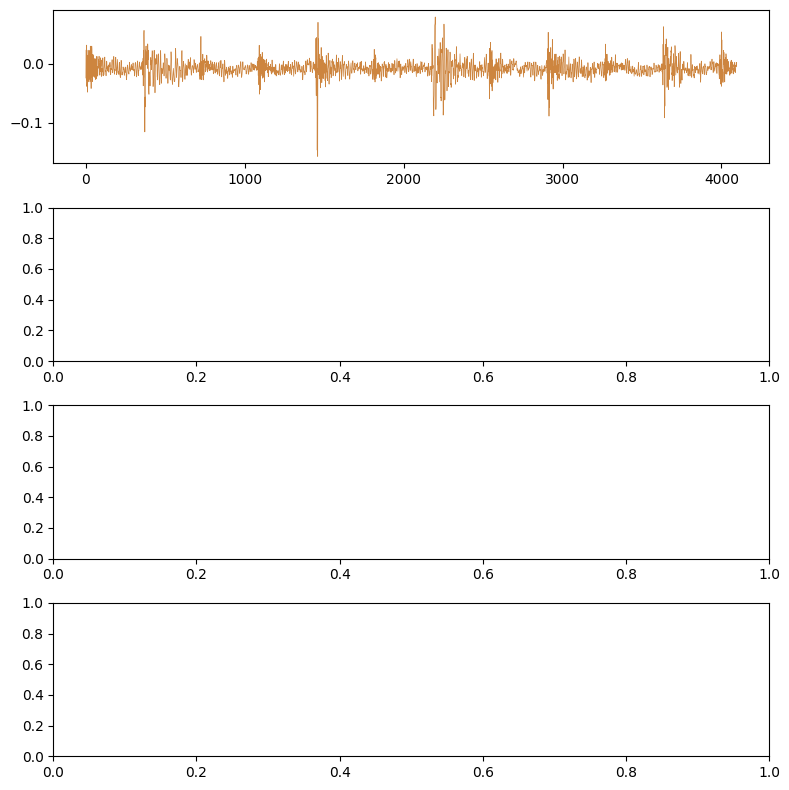

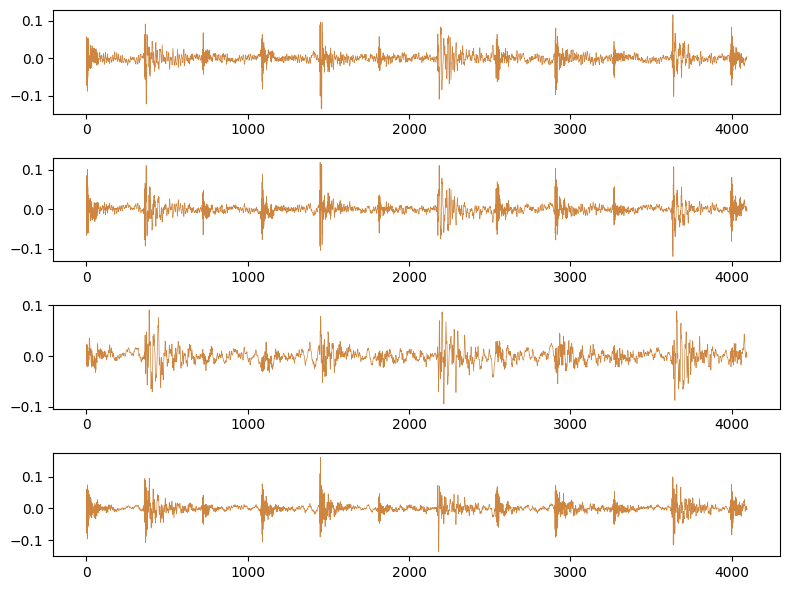

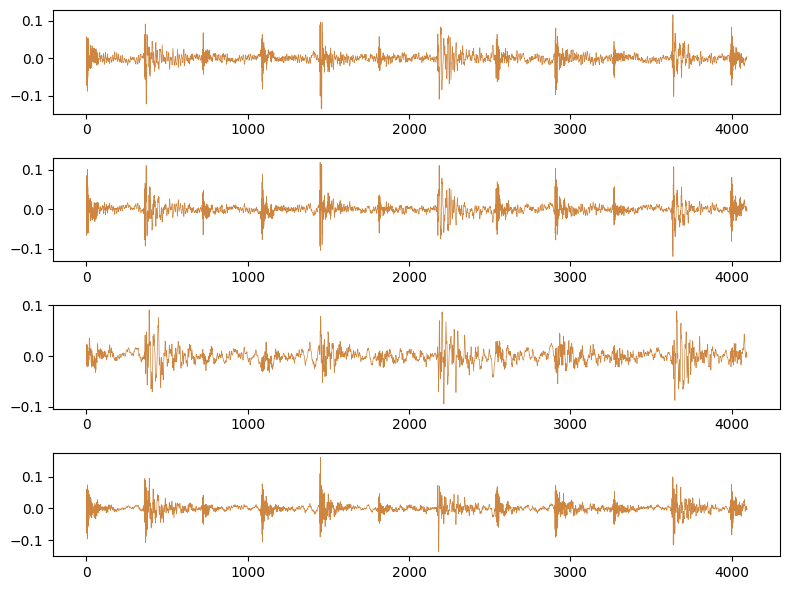

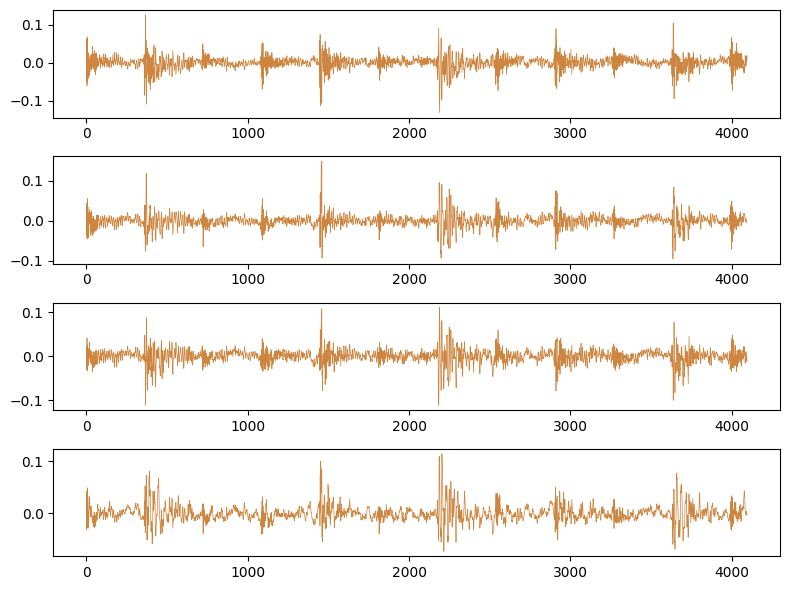

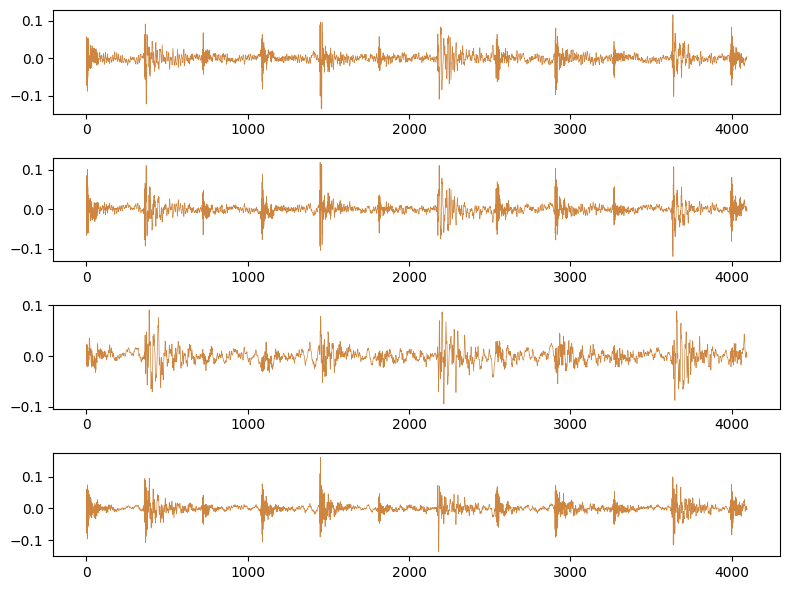

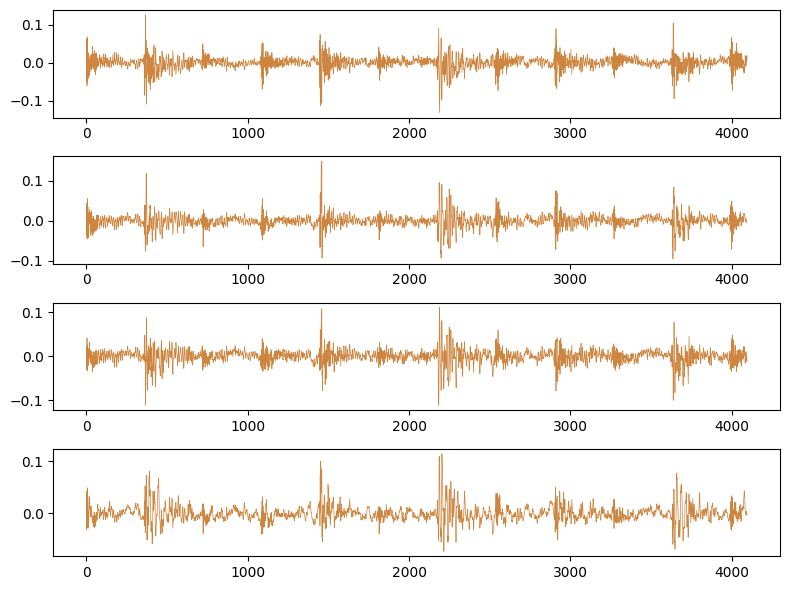

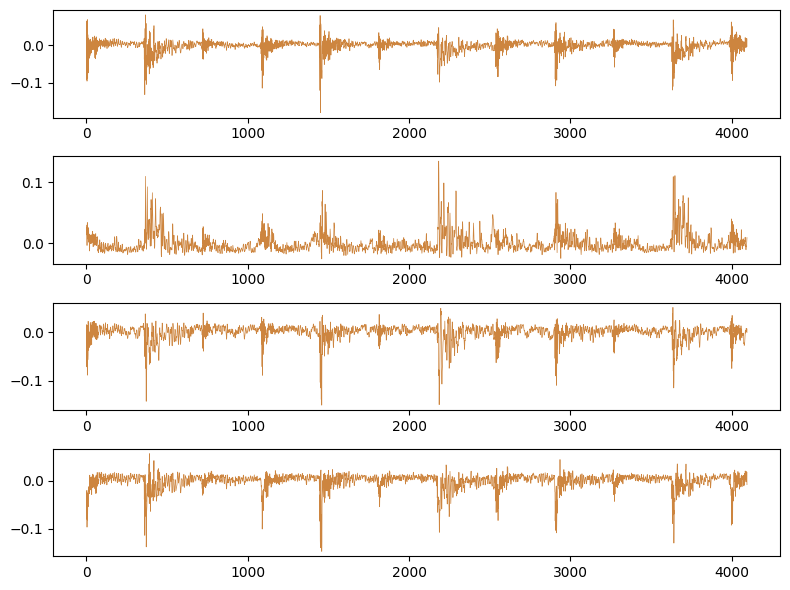

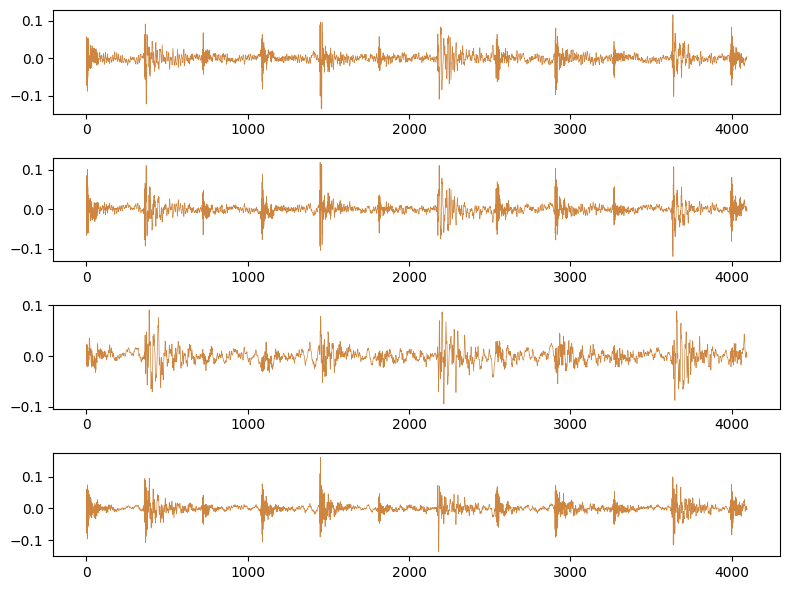

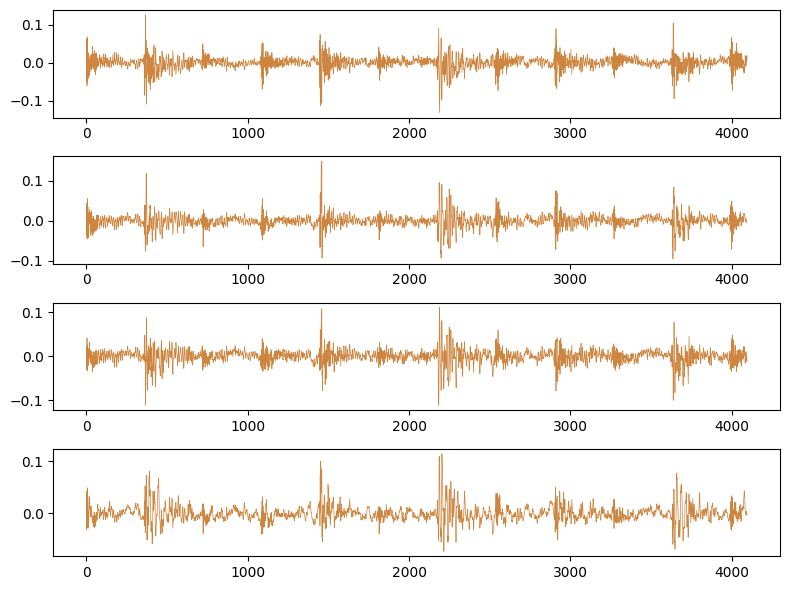

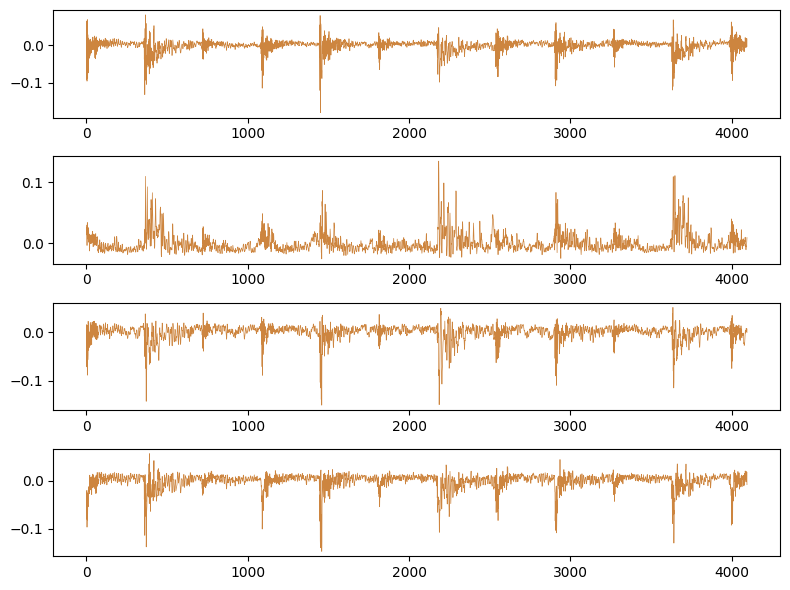

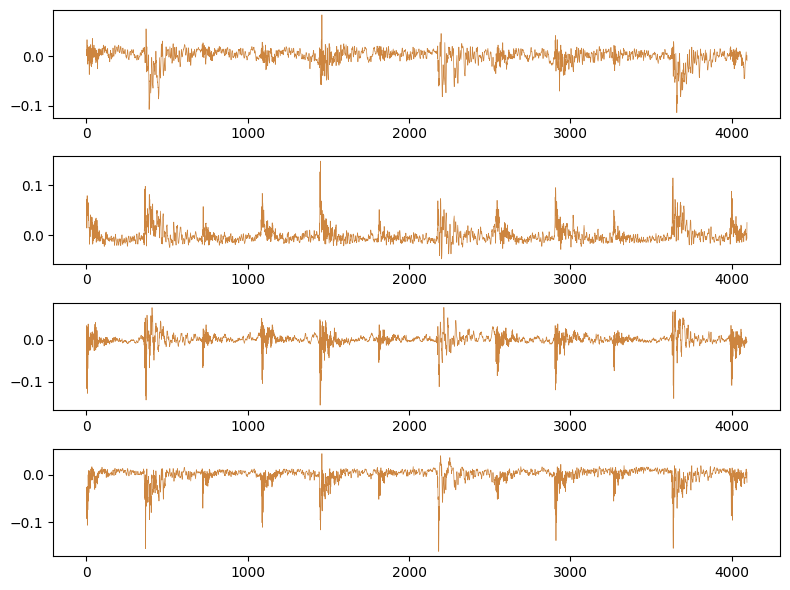

In [20]:
test_data = np.load("C:/Users/CCSLab/Desktop/HUST_bearing/HUST_bearing_20Hz_data.npy")
test_signal = torch.from_numpy(test_data).cuda().float()
test_signal_1 = test_signal[test_signal_num,:,:].unsqueeze(0)
fig, axs = plt.subplots(4, 1, figsize=(8, 8))
itime = F.normalize(test_signal_1[0,:,0],dim=0)
axs[0].plot(itime.detach().cpu().numpy(),linewidth=0.5 ,c='peru')
ifre = F.normalize(torch.abs(torch.fft.fft(test_signal_1[0,:,0])[:2048]),dim=0)
# axs[1].plot(ifre.detach().cpu().numpy(),linewidth=0.5 ,c='peru')
plt.savefig('save/figure/'+ f'signal_0.svg')

plt.tight_layout()
for i in range(4):
    model.network.signal_processing_layers[i].skip_connection.register_forward_hook(lambda module, input, output: hook_fn(module, input, output, savename=f'signal_{i+1}.svg'))
    model.eval()
    with torch.no_grad():
        output = model(test_signal)